
# Week 04: Neural networks and new classes

This week, we're going to learn a foundational shift in representation that will stage the rest of the class. These concepts *interconnect* with everything we have learned so far up to quiz01, and constitute the foundation for the rest of a career in an applied machine learning. These concepts are:

- Understanding the adaptation from Linear regression to Logistic regression, and the generalization of both to Neural Networks.
- Understanding the concept of a "class" in programming, and how to use classes to create new data types that can be used in your code.
- Starting to use classes to help us organize our ever growing training process.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## From Linear Models to Neural Networks

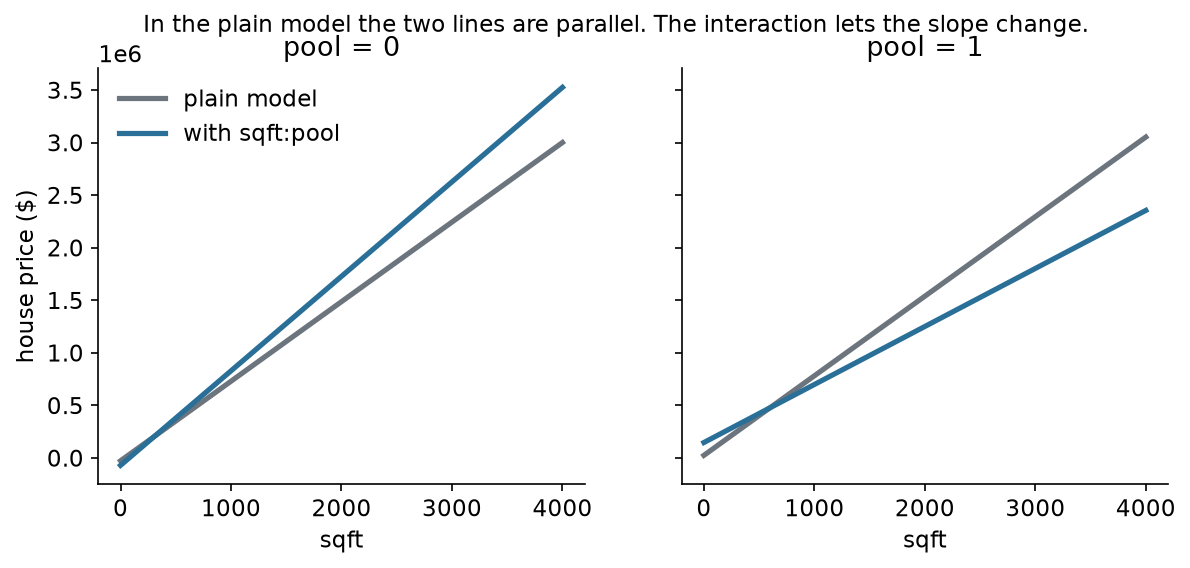
Source: https://mlu-explain.github.io/linear-regression/

house price, plain = $-27154 + 757*sqft + 51867*pool$

house price, interactive = $-70296 + 899*sqft + 217111*pool - 347*(sqft:pool)$

The most complex linear models we have seen are those that include interaction terms, which allow us to model the effect of one feature on the target variable while taking into account the presence of another feature. For example, in the interactive model above, we have two main effects:

- sqft: the size of the house in square feet
- pool: a binary variable indicating whether the house has a pool or not

This model allows us to capture the effect of having a pool on the house price, while also considering the size of the house. However, this model is still limited in its ability to capture complex relationships between features and the target variable.

For example, if we wanted to model the effect of having a pool on the house price while also considering the number of bedrooms, we would need to include another interaction term in our model,

house price, interactive = $-70296 + 899*sqft + 217111*pool - 347*(sqft:pool) + 5000*bedrooms - 1000*(bedrooms:pool)$

we should, by now, hopefully recognize this as an instance of *linear modeling*, a way to represent data using the same iterative method we've discussed: taking the linear combination of all modeled features, and then adding a bias term. This is the same as the equation y = mx + b, but with multiple features & interaction terms, i.e:

$$y = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b$$

Which is the modeling equation we first saw in automatic differentiation. We can understand this as a linear combination of all modeled features, where the set of weights

$${w_1, w_2, w_3, ..., w_n}$$

and the set of features,

$${x_1, x_2, x_3, ..., x_n}$$

are summed together, and then a bias term, b, is added to the result. This is called a linear combination.

Like the bias, an **activation function** can be used to introduce non-linearity into the model, allowing it to capture more complex relationships between features and the target variable without fundamentally changing the underlying linear representation. This is the key to understanding how we can use linear models to represent non-linear relationships in our data, and is the foundation of neural networks.

When a linear model needs to produce a probability, it runs into a problem: a linear output can be any number at all, while a probability has to sit between 0 and 1. The standard fix is to pass the linear output through a non-linear activation function. Specifically, the sigmoid function maps any weighted sum into a probability between 0 and 1. Here sigmoid is an **activation function**, that meaningfully transforms the output of our linear model into a different kind of representation, allowing us to model a more complex relationship!

These two ideas taken together, linear combinations and activation functions, are the foundation of neural networks, which are a powerful tool for modeling complex relationships in data. By combining multiple linear models with non-linear activation functions, we can create a network of interconnected nodes that can learn to represent complex relationships between **many** features and the target variable.

## Neurons

Now, we're going to describe all of the pieces of a neuron, or perceptron, which is the basic building block of a neural network, and it might sound a bit repetitive:

A neuron takes in a set of inputs, let's call that $x = {x_1, x_2, x_3, ..., x_n}$

These inputs are multiplied by a set of weights, $w = {w_1, w_2, w_3, ..., w_n}$

The weighted inputs are summed together, and a bias term, b, is added to the result. This can be represented mathematically as:

$$z = w_1x_1 + w_2x_2 + w_3x_3 + ... + w_nx_n + b$$

The output of the neuron is then passed through an activation function, which introduces non-linearity into the model. This allows the neuron to learn more complex patterns in the data.

That sounded repetitive, but is on purpose: a neuron is a linear model paired with the idea of an activation function, which allows us to model non-linear relationships in our data. This is the foundation of neural networks, which are composed of many neurons stacked together to form layers.

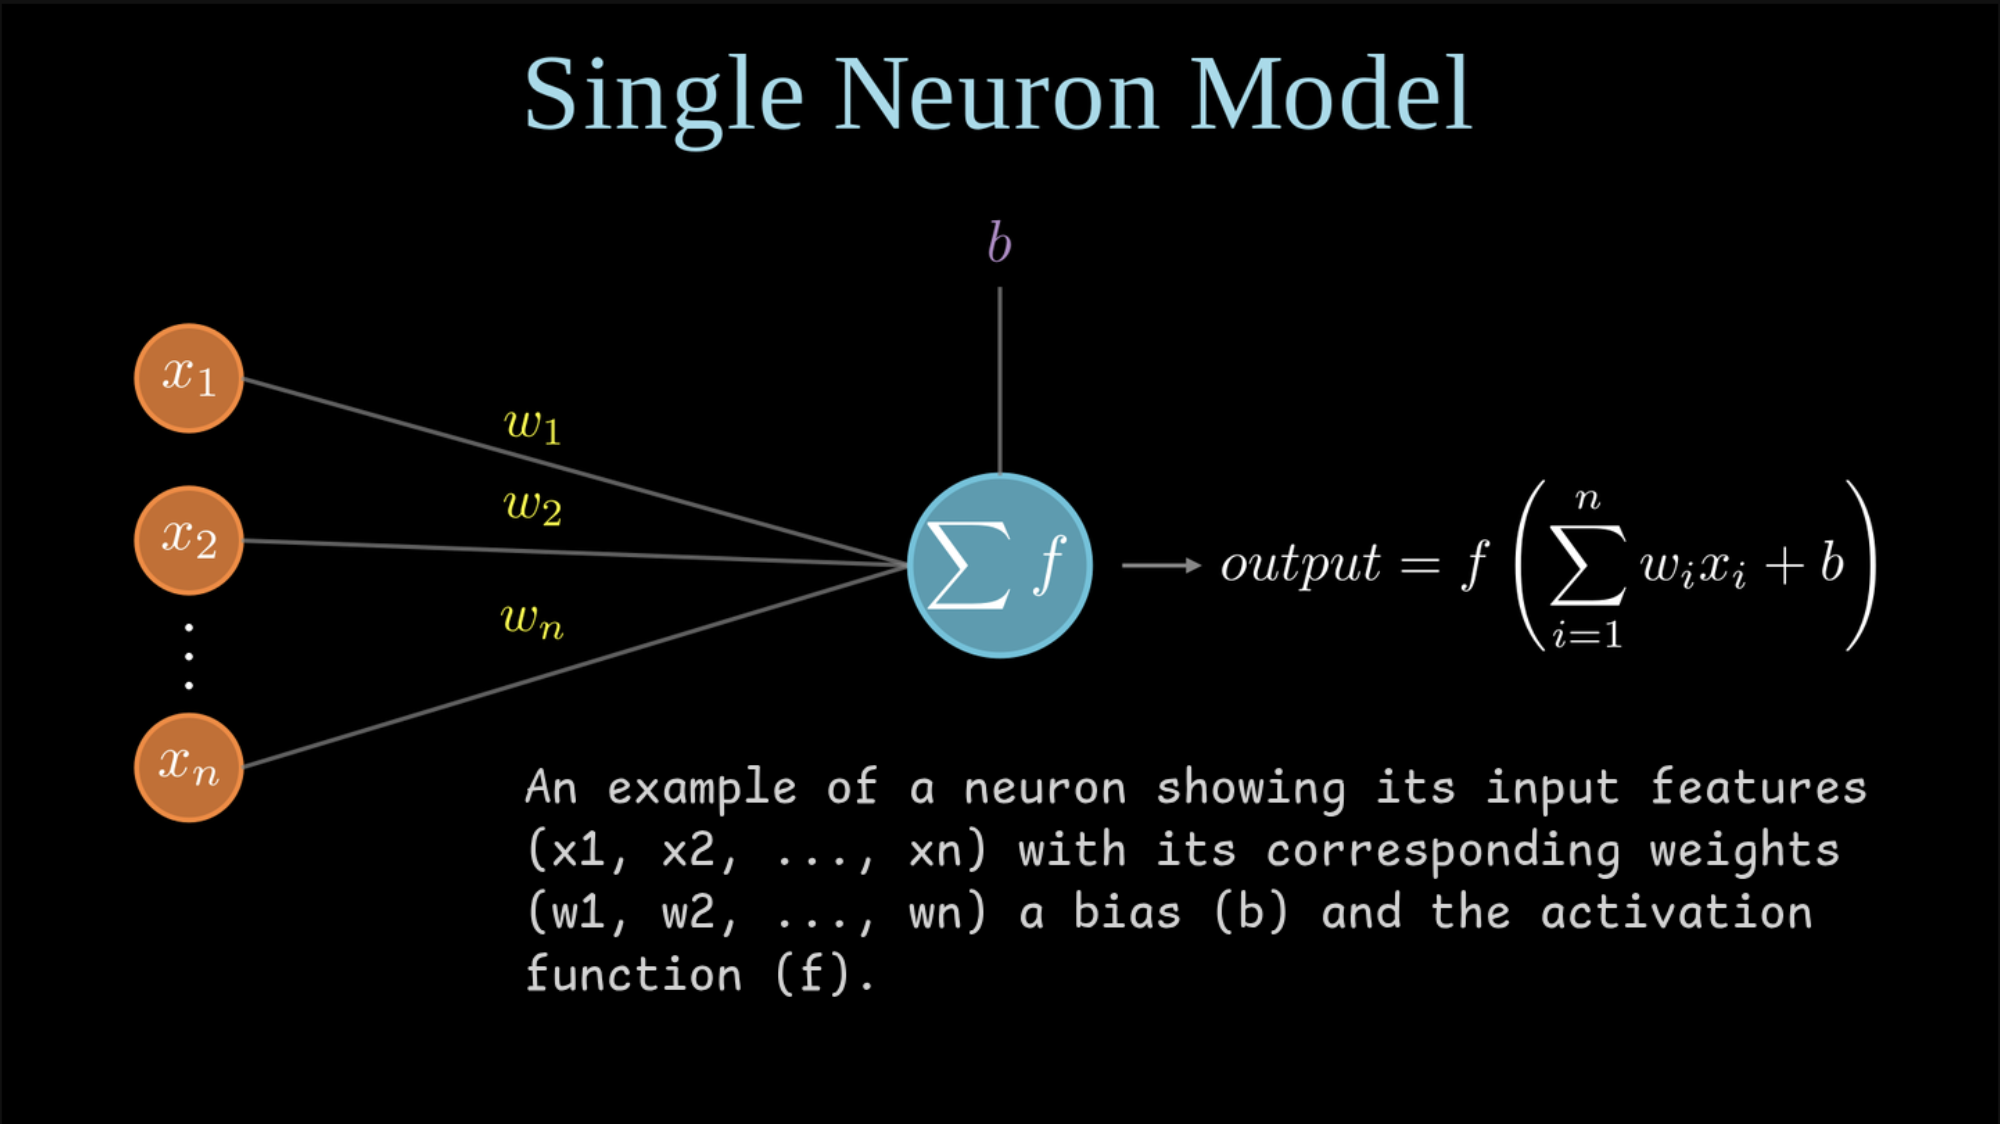
Source: https://github.com/rodmarkun/SmolML/tree/main/smolml/models/nn

## Neural Networks

When we stack a single layer of neurons together, we get a **single-layer neural network**. This is the simplest type of neural network, and it can be used to model simple relationships between features and the target variable. Here it's clear this is essentially no different than a linear model, other than we've bundled in the activation function by default.

When we stack multiple layers of neurons together, we get a **multi-layer neural network**, which can be used to model more complex relationships between features and the target variable. Each layer of neurons takes in the output of the previous layer as its input, allowing the network to learn hierarchical representations of the data.

Hidden layers are the layers of neurons that are not directly connected to the input or output of the network. These layers allow the network to learn more complex representations of the data, and they are critical for the success of deep learning models.

We describe the dimensions of a neural network in terms of the number of neurons in each layer, and the number of layers in the network.

- The input layer is the first layer of the network, and it takes in the input features.
- The output layer is the last layer of the network, and it produces the output predictions.
- The hidden layers are the layers in between the input and output layers, and they allow the network to learn more complex representations of the data.

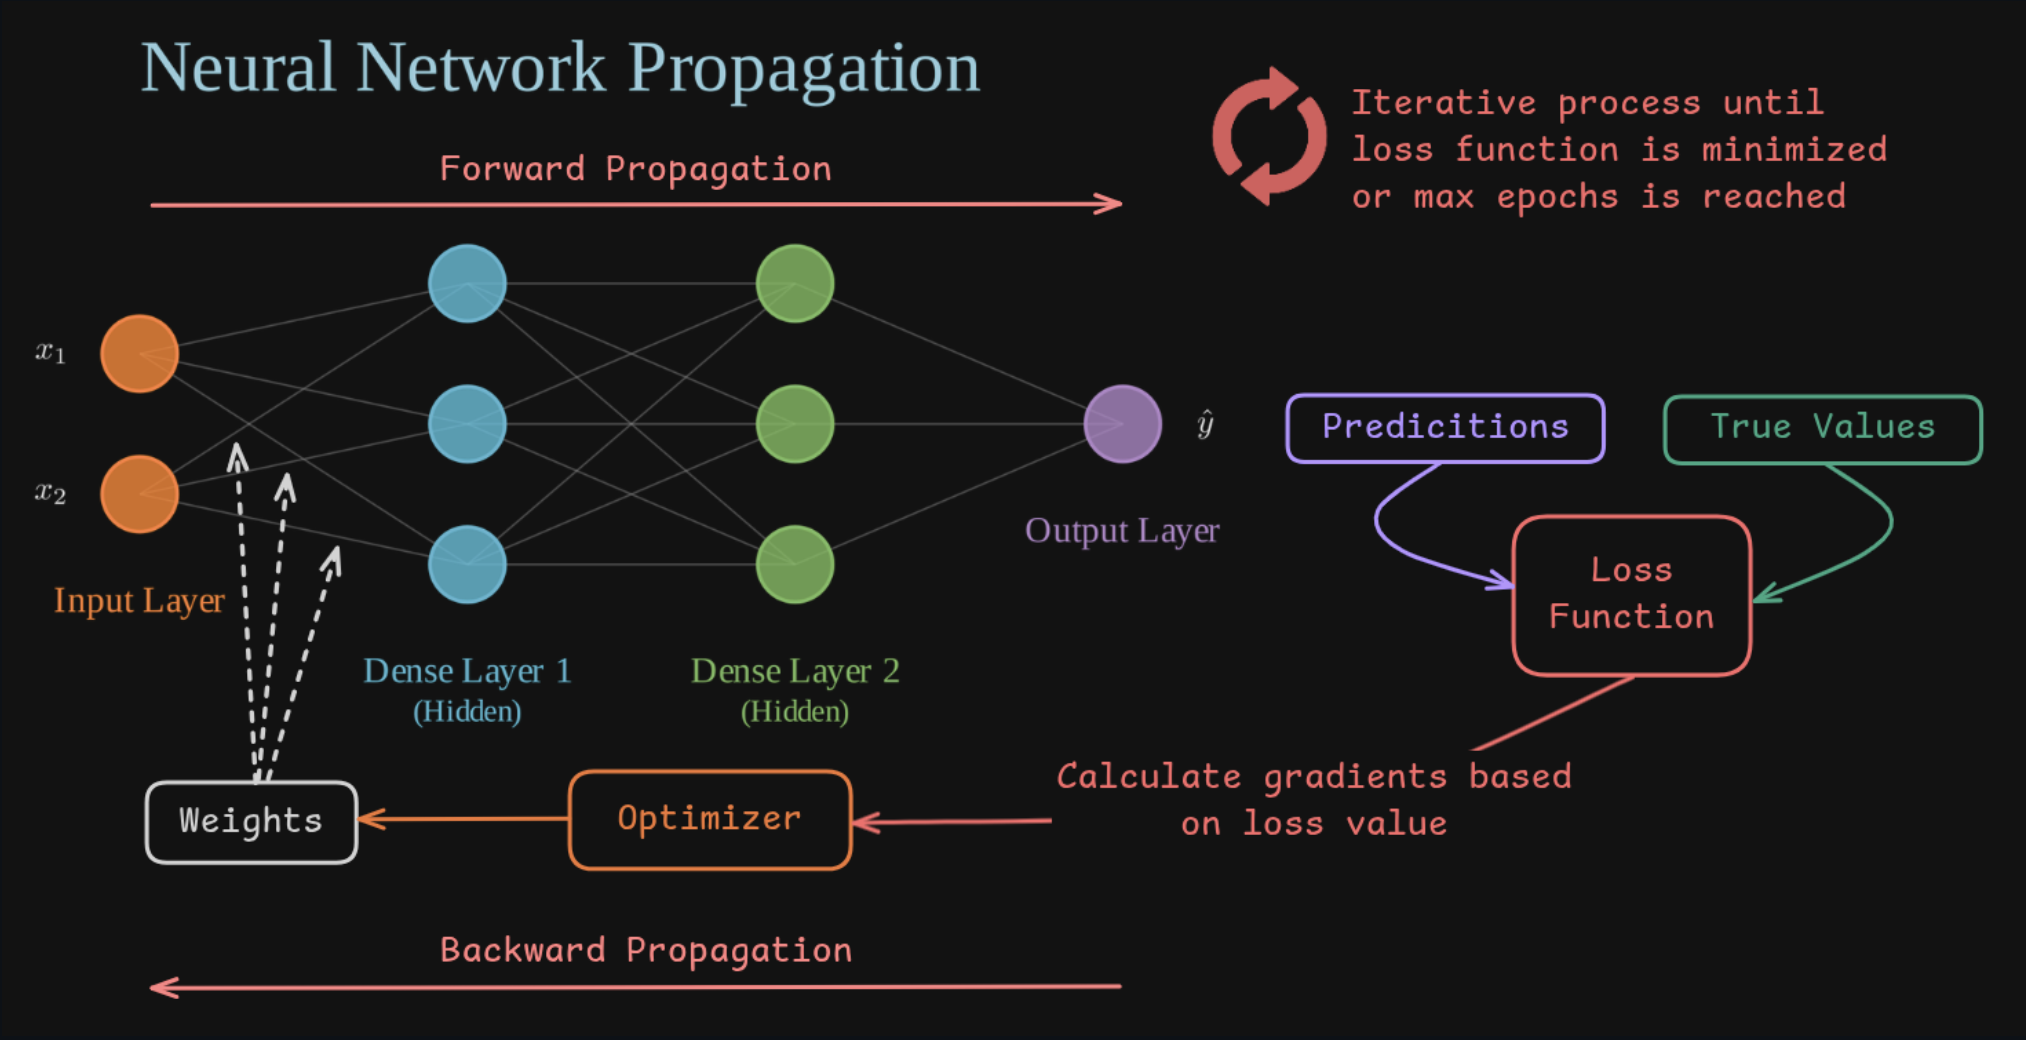
Source: https://github.com/rodmarkun/SmolML/tree/main/smolml/models/nn

### A layer is one matrix multiply

The picture above draws every neuron as its own circle, and it is easy to read that as one separate computation per circle. It is not. Every neuron in a layer looks at the same inputs, and only the weights differ. Stack those weight vectors as the columns of one matrix and the whole layer becomes a single matrix multiply, which is the operation we have been writing since week 01.

Here are sixteen neurons in one layer, computed one at a time the way the picture reads, and the same sixteen computed as a single matmul.

In [2]:
torch.manual_seed(0)

x_one = torch.randn(1, 2)          # one example, two features
W = torch.randn(2, 16)             # 16 neurons: one column of weights each
b = torch.randn(16)                # 16 biases: one per neuron

# one neuron at a time, the way the picture reads
by_hand = torch.stack([(x_one[0] * W[:, j]).sum() + b[j] for j in range(16)])

# the whole layer at once
by_matmul = (x_one @ W + b)[0]

print("sixteen neurons, computed one at a time:", tuple(by_hand.shape))
print("the same layer, computed as one matmul: ", tuple(by_matmul.shape))
print("biggest difference: %.1e" % (by_hand - by_matmul).abs().max().item())

sixteen neurons, computed one at a time: (16,)
the same layer, computed as one matmul:  (16,)
biggest difference: 1.2e-07


The width of a layer is a column count. `W` has 16 columns, so the layer has 16 neurons. Reading the shapes of the weight matrices is reading the architecture of the network, and this is why shapes get so much attention: they are not bookkeeping, they are the design.

Run a batch of 800 examples through a two-layer network and watch the second number change at each step. The first number stays the count of examples all the way through, because the network treats every example the same way. Only the second is ours to choose.

In [3]:
X_demo = torch.randn(800, 2)                        # 800 examples, 2 features each

W1_demo, b1_demo = torch.randn(2, 16), torch.zeros(16)
W2_demo, b2_demo = torch.randn(16, 1), torch.zeros(1)

h_demo = torch.relu(X_demo @ W1_demo + b1_demo)     # the hidden layer
y_demo = torch.sigmoid(h_demo @ W2_demo + b2_demo)  # the output layer

print("into the network     ", tuple(X_demo.shape))
print("after the first layer", tuple(h_demo.shape))
print("after the second     ", tuple(y_demo.shape))

into the network      (800, 2)
after the first layer (800, 16)
after the second      (800, 1)


### Width and depth buy different things

**Width** is how many bends you get in one round. Each neuron contributes one weighted sum and one bend, so a layer of 16 neurons hands the next layer 16 different views of the same input, built in parallel and all built from the same raw features.

**Depth** is how many rounds of composition you get. The second layer does not see the raw features at all. It sees the 16 views the first layer built, and it combines those. A third layer would combine what the second one built. This is what "hierarchical representation" means when you read it: each layer's features are made out of the previous layer's features, not out of the input.

Two things follow. A wide shallow network and a narrow deep network are not interchangeable, even when they have the same number of parameters, because they compose a different number of times. And the hidden layer's 16 outputs are features, in the same sense as any column you would have built by hand in a spreadsheet. The network made them. We will look directly at a set of them further down.

## Activations, in detail

Everything we fit in weeks 01 through 03 was a linear model: a weighted sum with no bend. The activation function is the only nonlinear ingredient in a neural network, and it is the one piece that turns linear modeling into something more. Take it out and every neuron, layer, and network is a line. So it is worth one full section of attention.

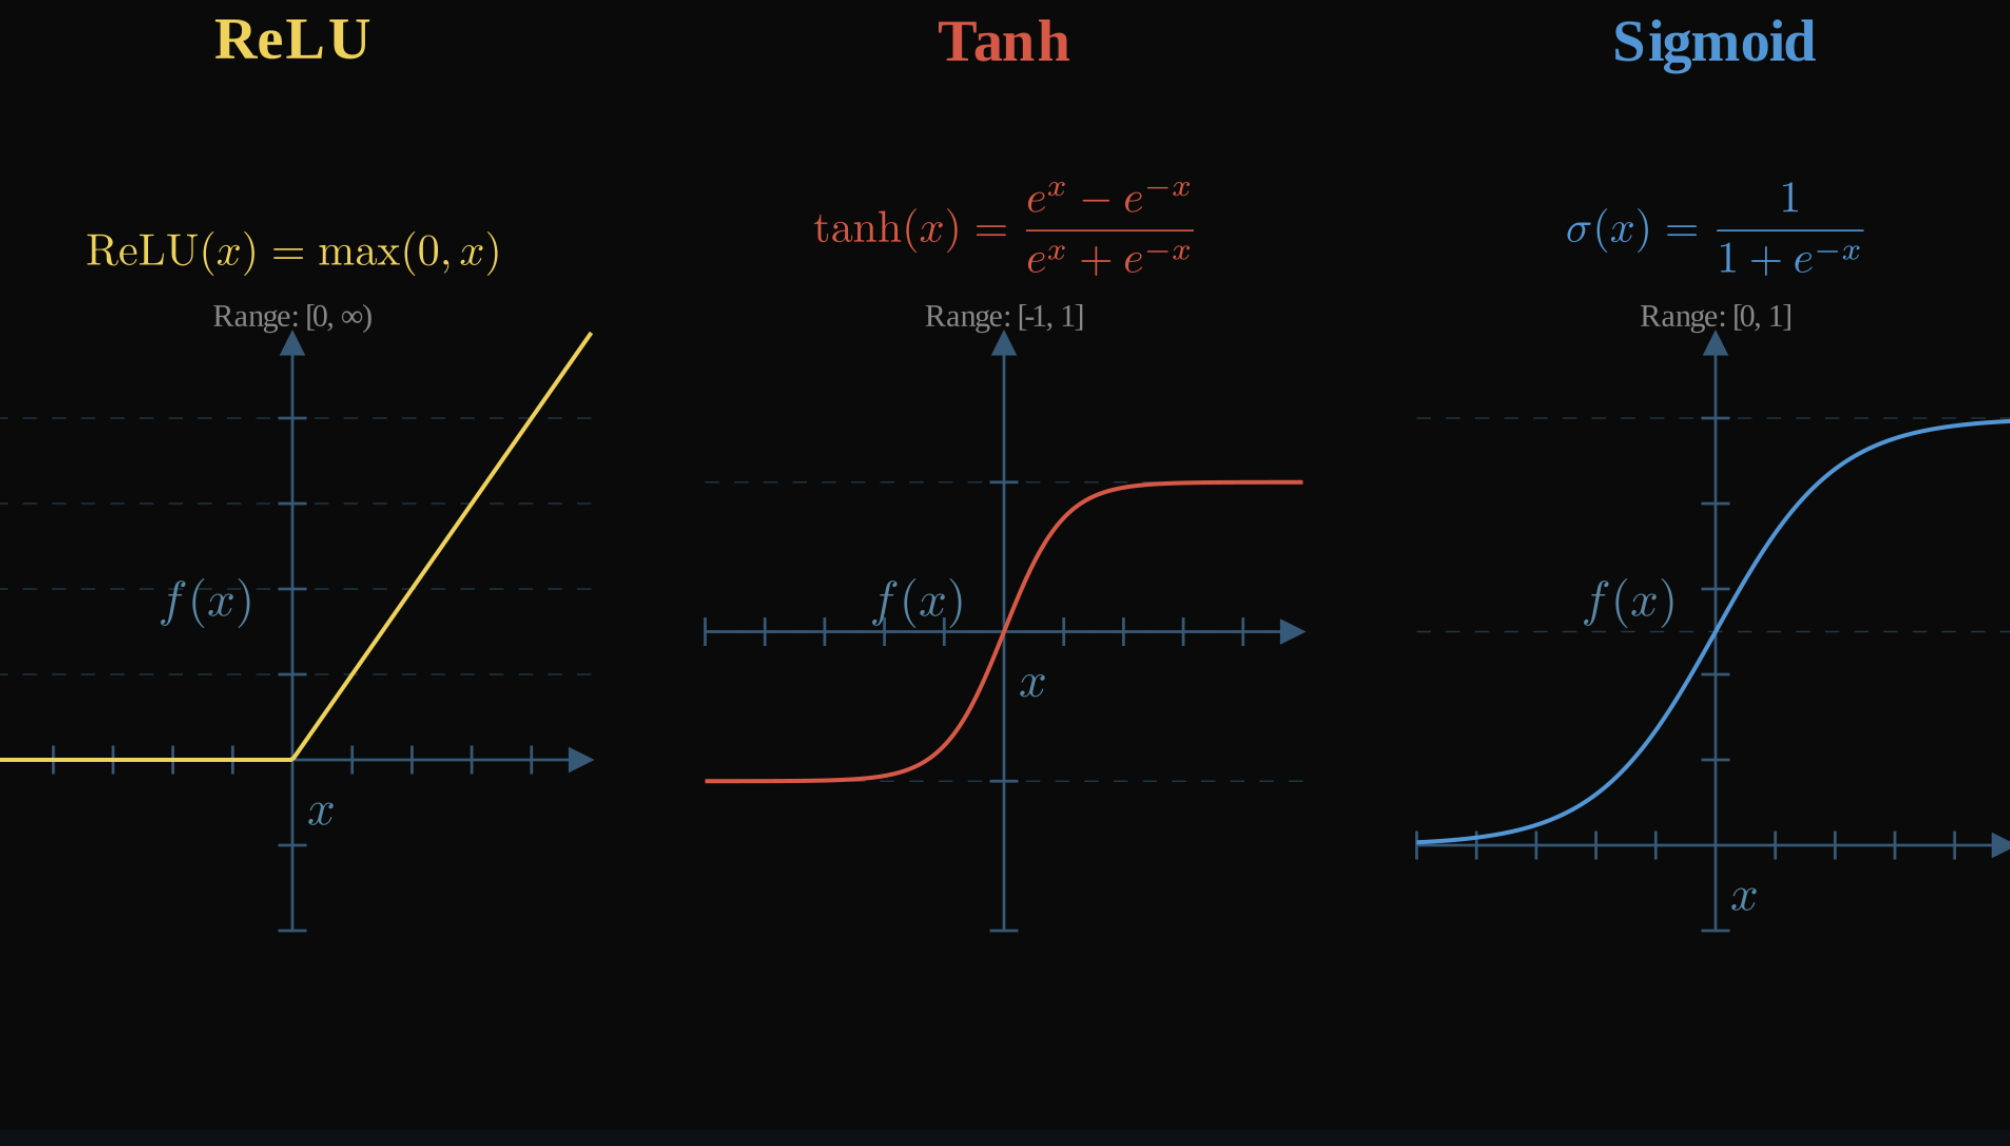
Source: https://github.com/rodmarkun/SmolML/tree/main/smolml/models/nn

Three curves there, and this week uses two of them. Tanh, in the middle, is a close relative of sigmoid that runs from -1 to 1 instead of 0 to 1. It shows up often enough to be worth recognizing, and we are not using it here. The two on the outside are the ones to know.

**Sigmoid** is the one we have used so far. It squashes any weighted sum into the range (0, 1), which is exactly what an output needs to do when we want to read it as a probability. It is monotone: a bigger sum always gives a bigger output. And it saturates: far from zero the curve goes flat, so a very large or very small sum barely moves the output at all. The flat tails also mean small gradients out there, which we will care about when we talk about training.

**ReLU**, short for rectified linear unit, is the new one, and it is the workhorse of hidden layers. It is simply max(0, x): zero for any negative sum, and the identity for any positive sum. A neuron with ReLU can be fully "off", contributing nothing, or "on", passing its sum straight through. It is cheap, and its positive side never saturates, so gradients keep flowing. And its single bend is exactly enough nonlinearity to matter, as the check below shows.

Why do two different activations live in two different places? Hidden layers want bends that keep gradients alive, and ReLU gives them. The output of a binary classifier wants a probability, and sigmoid gives one. Choosing an activation is a modeling choice, not an implementation detail.

Last week we checked something strange: two layers with nothing between them collapse into one, exactly. The 16 hidden units compute nothing that one weight matrix could not. Let's run that check again, and this time try it with both activations in between.

In [4]:
torch.manual_seed(0)

Xs = torch.randn(500, 2)
W1 = torch.randn(2, 6) / np.sqrt(2)
b1 = torch.zeros(6)
W2 = torch.randn(6, 1) * 0.5
b2 = torch.zeros(1)

# what the two layers would compute with NOTHING between them
two_identity = (Xs @ W1 + b1) @ W2 + b2

# the same computation, folded into a single layer
W_folded = W1 @ W2
b_folded = b1 @ W2 + b2
one_layer = Xs @ W_folded + b_folded

print("identity between the layers: difference from one layer %.2e"
      % (two_identity - one_layer).abs().max().item())

two_sigmoid = torch.sigmoid(Xs @ W1 + b1) @ W2 + b2
two_relu    = torch.relu(Xs @ W1 + b1) @ W2 + b2

print("sigmoid between the layers: difference from one layer %.3f"
      % (two_sigmoid - one_layer).abs().max().item())
print("ReLU between the layers:    difference from one layer %.3f"
      % (two_relu - one_layer).abs().max().item())

identity between the layers: difference from one layer 7.15e-07
sigmoid between the layers: difference from one layer 2.041
ReLU between the layers:    difference from one layer 2.702


The identity case collapses completely. With sigmoid or ReLU in between, no single linear layer can reproduce what the two layers compute. The activation is what makes depth real.

## One problem, three representations

Everything above was vocabulary. Here is the question the vocabulary was for: when the relationship in your data is not a straight line, who writes the features that make it one?

The problem below has two features and two classes. We will attack it three ways: with a line, with crossed features built by hand, and with a small network. All three get the same data, the same loss, and the same training routine. The only thing that differs is the representation.

X (800, 2)  t (800, 1)  share of class 1: 0.468


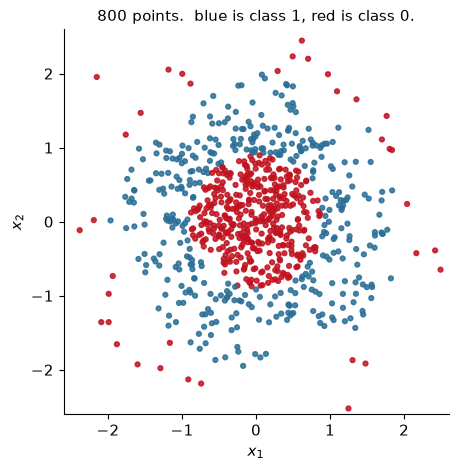

In [5]:
torch.manual_seed(0)

n = 800
X = torch.randn(n, 2) * 0.8              # two features, drawn around the origin
r = X.norm(dim=1)                        # distance from the origin
t = ((r > 0.9) & (r < 2.0)).float().reshape(-1, 1)   # the ring is class 1

RING, DISK = "#2a6f97", "#c1121f"
col = np.where(t[:, 0].numpy() > 0.5, RING, DISK)

print("X", tuple(X.shape), " t", tuple(t.shape), " share of class 1: %.3f" % t.mean().item())

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.scatter(X[:, 0], X[:, 1], c=col, s=12, alpha=0.85)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.6, 2.6)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("800 points.  blue is class 1, red is class 0.", fontsize=11)
plt.show()

Stop at the picture for a second and try the thing we have been doing all semester. Put a ruler down on it. Anywhere, at any angle. Can you get the blue on one side and the red on the other?

Here are three honest attempts.

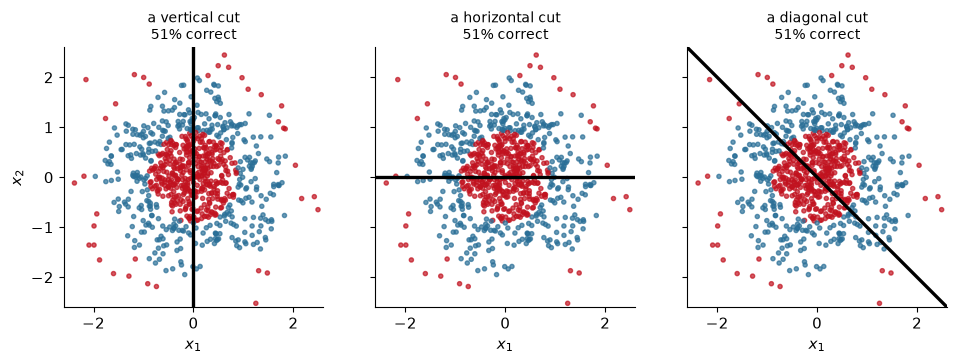

In [6]:
def straight_cut(nx, ny, c):
    """predict class 1 on one side of the line  nx*x1 + ny*x2 = c"""
    side = (X[:, 0] * nx + X[:, 1] * ny > c).float().reshape(-1, 1)
    return max((side == t).float().mean().item(),      # either side could be class 1,
               ((1 - side) == t).float().mean().item())  # so take the better reading

cuts = [(1.0, 0.0, 0.0, "a vertical cut"),
        (0.0, 1.0, 0.0, "a horizontal cut"),
        (0.7071, 0.7071, 0.0, "a diagonal cut")]

xs = np.linspace(-2.6, 2.6, 10)
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.9), sharey=True)
for ax, (nx, ny, c, name) in zip(axes, cuts):
    ax.scatter(X[:, 0], X[:, 1], c=col, s=9, alpha=0.7)
    if ny == 0:
        ax.axvline(c / nx, color="black", lw=2.4)
    else:
        ax.plot(xs, (c - nx * xs) / ny, color="black", lw=2.4)
    ax.set_xlim(-2.6, 2.6)
    ax.set_ylim(-2.6, 2.6)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_title("%s\n%.0f%% correct" % (name, 100 * straight_cut(nx, ny, c)), fontsize=10)
axes[0].set_ylabel("$x_2$")
plt.show()

All three land near 50%, which is what a coin flip gets. Rotating the line does not help, and sliding it does not help, because whichever half-plane you take, it holds about as much blue as red. There is no best line here. There is only a tie among bad ones.

### First way: a line

Fit one anyway, properly: logistic regression on the raw features, trained the way we have trained everything so far, with MSE as the loss and autograd for the gradients.

In [7]:
torch.manual_seed(0)

w_lin = torch.randn(2, 1) * 0.1
b_lin = torch.zeros(1)

for p in (w_lin, b_lin):
    p.requires_grad_(True)

for step in range(3000):
    for p in (w_lin, b_lin):
        if p.grad is not None:
            p.grad.zero_()
    loss = ((torch.sigmoid(X @ w_lin + b_lin) - t) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        for p in (w_lin, b_lin):
            p -= 1.0 * p.grad

line_model = lambda g: torch.sigmoid(g @ w_lin + b_lin)

with torch.no_grad():
    acc_line = ((line_model(X) > 0.5).float() == t).float().mean().item()
    share_called_1 = (line_model(X) > 0.5).float().mean().item()
baseline = max(t.mean().item(), 1 - t.mean().item())

print("accuracy                                      %.3f" % acc_line)
print("accuracy from ignoring x1 and x2 entirely and")
print("always guessing the bigger class              %.3f" % baseline)
print("share of points this model calls class 1      %.3f" % share_called_1)

accuracy                                      0.527
accuracy from ignoring x1 and x2 entirely and
always guessing the bigger class              0.532
share of points this model calls class 1      0.005


Read the third number. Gradient descent did not find a clever line. It found the exit: call almost everything the same class and collect the score that guessing already pays. That is what "a tie among bad ones" looks like from the optimizer's side, and it is why there is no boundary worth drawing here. A line is the wrong representation, and no amount of training fixes a representation.

### Second way: crossed features, built by hand

The interaction term at the top of this notebook multiplied two features together so that one could change the effect of the other. Feature crossing is that idea taken to its limit. Instead of one product, chop each feature into bins and give every pair of bins its own feature.

Start with the chopping. Six bins per feature turns the plane into a grid of 36 cells.

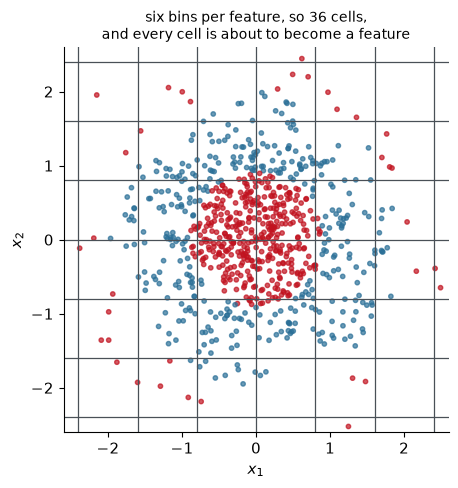

In [8]:
edges = torch.linspace(-2.4, 2.4, 7)      # six bins per feature, shared edges

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.scatter(X[:, 0], X[:, 1], c=col, s=10, alpha=0.7)
for e in edges:
    ax.axvline(float(e), color="#495057", lw=0.9)
    ax.axhline(float(e), color="#495057", lw=0.9)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.6, 2.6)
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("six bins per feature, so 36 cells,\nand every cell is about to become a feature", fontsize=10)
plt.show()

To build the features we ask each point which bin it falls into on each axis, then switch on the single feature belonging to that pair of bins. Take the first point in the data and follow it through.

In [9]:
def one_hot(idx):
    return torch.eye(6)[idx]

def crossed_features(g):
    i1 = torch.bucketize(g[:, 0].contiguous(), edges[1:-1])    # which bin along x1
    i2 = torch.bucketize(g[:, 1].contiguous(), edges[1:-1])    # which bin along x2
    return (one_hot(i1).unsqueeze(2) * one_hot(i2).unsqueeze(1)).reshape(len(g), 36)

pt = X[0:1]
i1 = int(torch.bucketize(pt[:, 0].contiguous(), edges[1:-1]))
i2 = int(torch.bucketize(pt[:, 1].contiguous(), edges[1:-1]))
row = crossed_features(pt)[0]

print("the point            (%.2f, %.2f)" % (pt[0, 0], pt[0, 1]))
print("bin along x1         %d" % i1)
print("bin along x2         %d" % i2)
print("so cell number       %d  (row %d, column %d of the grid)" % (i1 * 6 + i2, i1, i2))
print("its 36 features      %s" % row.int().tolist())

the point            (-0.90, -0.92)
bin along x1         1
bin along x2         1
so cell number       7  (row 1, column 1 of the grid)
its 36 features      [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


That is one row of the feature matrix: 36 numbers, 35 of them zero, and a single 1 meaning "x1 landed in this bin and x2 landed in that one." Nothing about the shape of the data is in there. The model will never learn that the boundary is round. It will learn 36 separate answers to 36 separate questions of the form "what happens in this cell?"

Build them for every point and fit the same logistic model on the crosses.

In [10]:
cross = crossed_features(X)
print("crossed features", tuple(cross.shape), " one for every pair of bins")

torch.manual_seed(0)

w_cross = torch.randn(36, 1) * 0.1
b_cross = torch.zeros(1)

for p in (w_cross, b_cross):
    p.requires_grad_(True)

for step in range(3000):
    for p in (w_cross, b_cross):
        if p.grad is not None:
            p.grad.zero_()
    loss = ((torch.sigmoid(cross @ w_cross + b_cross) - t) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        for p in (w_cross, b_cross):
            p -= 1.0 * p.grad

crossed_model = lambda g: torch.sigmoid(crossed_features(g) @ w_cross + b_cross)

with torch.no_grad():
    acc_cross = ((crossed_model(X) > 0.5).float() == t).float().mean().item()
print("accuracy %.3f" % acc_cross)

crossed features (800, 36)  one for every pair of bins


accuracy 0.918


Now there is something worth drawing. Every model from here on gets shown the same way: the same cloud, with a single line marking where the model switches from calling a point class 0 to calling it class 1.

In [11]:
grid_x = np.linspace(-2.6, 2.6, 200)
GX, GY = np.meshgrid(grid_x, grid_x)
G = torch.tensor(np.stack([GX.ravel(), GY.ravel()], axis=1), dtype=torch.float32)

def show_model(ax, f, title):
    ax.scatter(X[:, 0], X[:, 1], c=col, s=9, alpha=0.55)
    with torch.no_grad():
        z = f(G).reshape(len(grid_x), len(grid_x)).numpy()
    ax.contour(grid_x, grid_x, z, levels=[0.5], colors=["black"], linewidths=2.4)
    ax.set_xlim(-2.6, 2.6)
    ax.set_ylim(-2.6, 2.6)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_title(title, fontsize=10)

And because there is exactly one weight per cell, we can also put the 36 weights back into the grid they came from and look straight at what the model learned.

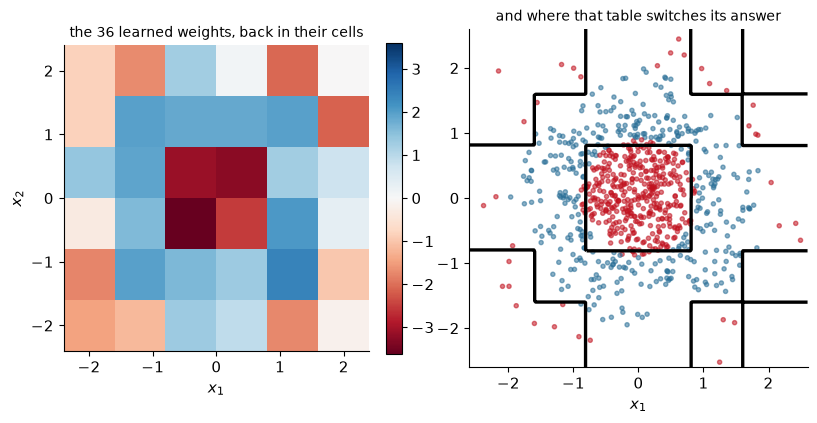

In [12]:
Wg = w_cross.detach().reshape(6, 6).numpy()
lim = np.abs(Wg).max()

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4))
im = axes[0].imshow(Wg.T, origin="lower", cmap="RdBu", vmin=-lim, vmax=lim,
                    extent=[-2.4, 2.4, -2.4, 2.4])
axes[0].set_title("the 36 learned weights, back in their cells", fontsize=10)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_aspect("equal")
fig.colorbar(im, ax=axes[0], fraction=0.046)
show_model(axes[1], crossed_model, "and where that table switches its answer")
plt.show()

There is the shape, drawn cell by cell. Blue cells hold a positive weight and vote for class 1, red cells hold a negative weight and vote for class 0, and the colors line up with the points because that is genuinely all the weights are: a lookup table with the answer written into every square.

Sit with that, because it cuts both ways. This model is completely interpretable, and reading it teaches you nothing you did not already know, since what you are reading back is the data you put in. It never discovered that the boundary is round. It found 36 numbers, and the staircase in the right-hand panel is the grid we drew showing through.

Two costs come with that, and both are visible in this run.

In [13]:
counts = cross.sum(dim=0).reshape(6, 6)
print("training points per cell:")
print(counts.int().numpy())
print("\ncells with no data at all:", int((counts == 0).sum()), "out of 36")

print("\nhow the table grows:")
for k in (2, 3, 4):
    print("  %d features, 6 bins each:  %6d crossed features" % (k, 6 ** k))
print("  2 features, 20 bins each: %6d crossed features" % 20 ** 2)

training points per cell:
[[  2   3   4  10   1   1]
 [  4  12  34  36  20   3]
 [  9  35  88 101  43   4]
 [  2  26  87 102  43  13]
 [  3  26  23  25  12   5]
 [  0   1  12   5   5   0]]

cells with no data at all: 2 out of 36

how the table grows:
  2 features, 6 bins each:      36 crossed features
  3 features, 6 bins each:     216 crossed features
  4 features, 6 bins each:    1296 crossed features
  2 features, 20 bins each:    400 crossed features


The first cost is that every cell learns alone. A cell holding no training points has nothing to learn from, so its weight stays wherever it was initialized and the model's answer there is a guess nobody ever checked. A cell holding two points learns from two points. Neighboring cells cannot help each other, because as far as the model is concerned they are unrelated columns that happen to be printed next to each other.

The second cost is that the table grows as a power of the number of features. Two features at six bins is 36 weights. Four features is 1296. Ask for a smoother boundary instead of a staircase, and twenty bins on two features is already 400. Every one of those numbers is also a decision some person had to make: how many bins, where to cut them, which features to cross with which.

So the hand way works, and it cost us the bin edges, the cross enumeration, and one weight for every square of a grid we drew ourselves.

### Third way: a small network

A two-layer network on the raw features. No bins, no crosses, no grid. This is the exact code shape from week 03: parameters, forward pass, loss, backward, update. The only new thing is the problem it is pointed at.

accuracy 0.945


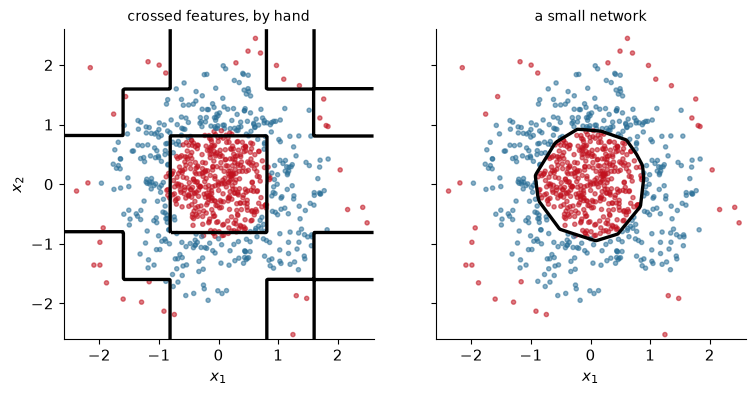

In [14]:
torch.manual_seed(0)

W1 = torch.randn(2, 16) / np.sqrt(2)     # feature -> hidden weights
b1 = torch.zeros(16)                     # hidden biases
W2 = torch.randn(16, 1) * 0.5            # hidden -> output weights
b2 = torch.zeros(1)                      # output bias

for p in (W1, b1, W2, b2):
    p.requires_grad_(True)

for step in range(5000):
    for p in (W1, b1, W2, b2):
        if p.grad is not None:
            p.grad.zero_()
    h = torch.relu(X @ W1 + b1)              # the hidden layer: 16 neurons
    y_hat = torch.sigmoid(h @ W2 + b2)       # the output: one probability
    loss = ((y_hat - t) ** 2).mean()         # our loss, MSE
    loss.backward()
    with torch.no_grad():
        for p in (W1, b1, W2, b2):
            p -= 1.0 * p.grad

hand_rolled_loss = loss.item()

net_model = lambda g: torch.sigmoid(torch.relu(g @ W1 + b1) @ W2 + b2)

with torch.no_grad():
    acc_net = ((net_model(X) > 0.5).float() == t).float().mean().item()
print("accuracy %.3f" % acc_net)

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.4), sharey=True)
show_model(axes[0], crossed_model, "crossed features, by hand")
show_model(axes[1], net_model, "a small network")
axes[0].set_ylabel("$x_2$")
plt.show()

Handed two raw features and nothing else, the network found the shape, and found it without corners. So ask it the same question we asked the lookup table: what did it actually learn?

The hidden layer has 16 units, and each one computes a weighted sum of $x_1$ and $x_2$ with a ReLU on the end. A weighted sum of two features is a tilted plane, and ReLU flattens everything below zero, so one hidden unit is a ramp with a hard edge: off on one side of a line, rising on the other. Sixteen units, sixteen lines. Here are all of them, drawn over the same plane as the data.

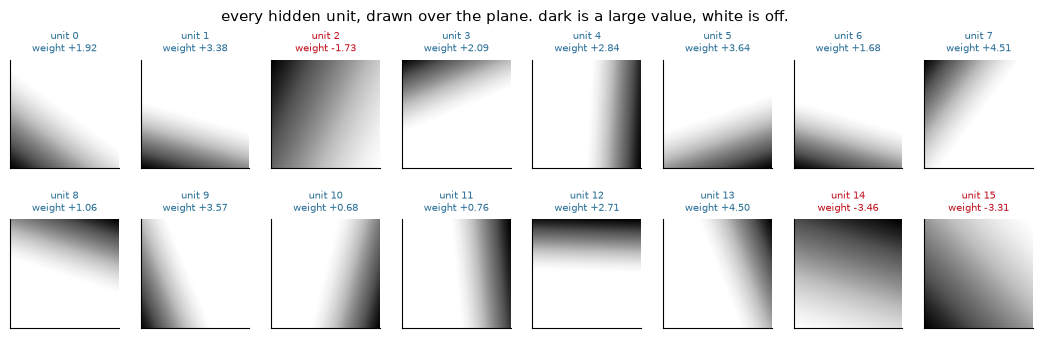

In [15]:
with torch.no_grad():
    H = torch.relu(G @ W1 + b1).reshape(len(grid_x), len(grid_x), 16).numpy()
    w_out = W2.detach().squeeze()

fig, axes = plt.subplots(2, 8, figsize=(13.2, 3.8))
for j, ax in enumerate(axes.ravel()):
    ax.imshow(H[:, :, j], origin="lower", extent=[-2.6, 2.6, -2.6, 2.6], cmap="Greys")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("unit %d\nweight %+.2f" % (j, w_out[j]), fontsize=7,
                 color=RING if w_out[j] > 0 else DISK)
fig.suptitle("every hidden unit, drawn over the plane. dark is a large value, white is off.",
             fontsize=11)
plt.show()

Not one of them is a circle. Every one is the simplest thing a neuron can be, a line with an off side, and the only difference between them is where that line sits and which way it faces. Each one on its own is exactly as useless as the three ruler cuts we tried at the top.

These are the network's features, in the same sense that the 36 crossed columns were features. The difference is that nobody chose them, and there are 16 rather than 36.

The output layer then takes a weighted vote over those 16 ramps. That vote is the number printed above each panel, blue arguing for class 1 and red against. Add the votes in one at a time, loudest first, and watch a closed shape come out of straight lines.

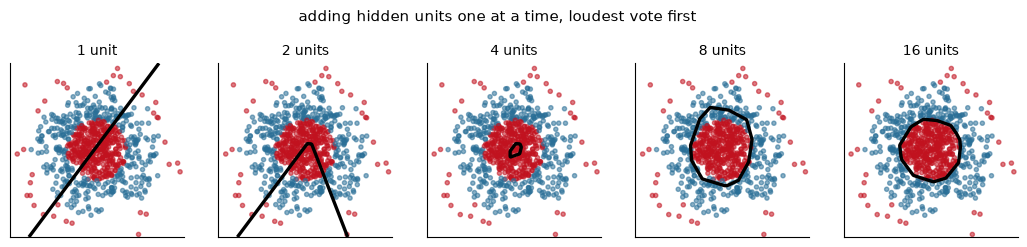

In [16]:
order = W2.detach().abs().squeeze().argsort(descending=True)

def partial_net(g, k):
    keep = torch.zeros_like(W2)
    keep[order[:k]] = W2[order[:k]]           # only the k loudest votes count
    return torch.sigmoid(torch.relu(g @ W1 + b1) @ keep + b2)

ks = [1, 2, 4, 8, 16]
fig, axes = plt.subplots(1, len(ks), figsize=(13.0, 2.9), sharey=True)
for ax, k in zip(axes, ks):
    show_model(ax, lambda g, k=k: partial_net(g, k), "%d unit%s" % (k, "" if k == 1 else "s"))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
fig.suptitle("adding hidden units one at a time, loudest vote first", fontsize=11)
plt.show()

One unit is a line, and it does no better than the ruler did. Two is a wedge. By eight the votes have fenced the red in from every side, and with all sixteen the fence is round enough to pass for a circle. A circle made of sixteen straight pieces is not really a circle, and it does not need to be. It needs to separate the data.

### The three, side by side

In [17]:
n_line = w_lin.numel() + b_lin.numel()
n_cross = w_cross.numel() + b_cross.numel()
n_net = sum(p.numel() for p in (W1, b1, W2, b2))

print("%-28s %-10s %s" % ("representation", "accuracy", "parameters"))
for name, acc, npar in (("a line", acc_line, n_line),
                        ("crossed features, by hand", acc_cross, n_cross),
                        ("a small network", acc_net, n_net)):
    print("%-28s %-10.3f %d" % (name, acc, npar))

representation               accuracy   parameters
a line                       0.527      3
crossed features, by hand    0.918      37
a small network              0.945      65


Three representations of one problem. The line had nowhere to bend, so it quit and guessed. The crossed model bent wherever we told it a cell boundary was, which is exactly why its shape is a staircase. The network bent wherever the data put a bend.

Notice that the network is not the small one. It carries more parameters than the lookup table does, and it is not compressing anything. Its 65 numbers went into building 16 features; the table's 37 went into memorizing 36 cells. Same problem, similar budget, spent on completely different things.

That is the shift this week is about, and every tool in the rest of this notebook exists to make the third row easy to write.

## Why, in general, is it important that we learn these neural networks to serve as a representation?

Essentially, they enable us to represent complex relationships in our data that are not easily captured by simple linear models. Neural networks can model non-linearities and interactions between features, making them powerful tools for a wide range of applications, from image recognition to natural language processing. This can roughly be thought of as the ability of various models to create conformal slices towards the problem/data, and by this I mean, we can teach our linear equations to "bend" and "twist" in ways that allow them to better fit the data, which is a critical step in creating models that generalize well to unseen data.

## Our new tool: nn.Module

So, in order to leverage the powerful effect of being able to model *many* different functions or equations at once, and then further, consider the partial derivatives with respect to how these equations are impacting one another, we need an object that can hold a whole network at once: its parameters, its forward pass, and its gradients. That object is `nn.Module`.

## Abstracting our training loop

As of now, we've had some difficulty relating to what is part of our model, and what is part of our data. This is because we have been using a very simple representation of our model, and our training process has been very simple as well, we've been effectively representing both our model and our training process as a single linear function, and this step can now be decomposed into a more modular approach.

We will start to use classes to help us organize our ever growing training process. As of now, we have the following components in some way:

Our data, which we have been storing in pandas DataFrames & accessing like so:

In [18]:
penguins = sns.load_dataset("penguins")
penguins[["species", "flipper_length_mm", "body_mass_g"]].head()

,species,flipper_length_mm,body_mass_g
0,Adelie,181.0,3750.0
1,Adelie,186.0,3800.0
2,Adelie,195.0,3250.0
3,Adelie,NaN,NaN
4,Adelie,193.0,3450.0


Our "models" so far have been linear functions, but we will start to use classes to represent models, and the training process. These classes specifically allow us to create and interact with neural networks directly as our representation, while retaining all of the flexibility of the underlying linear algebra.

Our training process of:

- Using our MSE loss function
- Using our gradient descent optimization function, in this case, we are still using the "vanilla" gradient descent from week 03, but later in this notebook we will meet "stochastic gradient descent" (SGD) and Adaptive Moment Estimation (Adam).
- As it may be clear here, that is only evaluation and optimization, we've been skipping the "representation" step proper, and instead simply thinking of how we're manipulating our data to better understand it.

We will also start to organize our data into a more modular approach: introducing the concept of dataloaders and datasets, which will allow us to separate the data from the model and training process more easily. This will make our code more reusable and easier to maintain.

The rest of this notebook replaces one hand-rolled step at a time with an object that does it. At every step the same model, trained the same way, gives the same numbers. What changes is how much of the bookkeeping we write ourselves.

### First rung: the model as a class

Before the new tool, let's take the first step with the tool we already have. Here is one of our own models, the linear model we fit at the start of the last section, wrapped as a class. Week 00's Counter pattern, doing real work.

In [19]:
class LinearModel:
    def __init__(self):
        self.w = torch.randn(2, 1) * 0.1
        self.b = torch.zeros(1)

    def forward(self, x):
        return torch.sigmoid(x @ self.w + self.b)   # logistic: a score bent into (0, 1)

torch.manual_seed(0)
m = LinearModel()
print(m.forward(X[:3]))

tensor([[0.4721],
        [0.4948],
        [0.5221]])


The class holds the parameters and computes the prediction. That is all it does. Everything else, the parameter bookkeeping, the gradient zeroing, the update, still lives outside it, in the training loop. The next rung moves those jobs inside the object.

### Second rung: nn.Module

`nn.Module` is PyTorch's base class for models. Subclass it, register your parameters in `__init__`, define `forward`, and the bookkeeping comes for free: `.parameters()` returns exactly the list we used to write by hand, and `.zero_grad()` clears every gradient at once. Week 00 told us "a PyTorch module is a class"; now we can see why that matters. Every model in PyTorch speaks this protocol.

In [20]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.W1 = nn.Parameter(torch.randn(2, 16) / np.sqrt(2))
        self.b1 = nn.Parameter(torch.zeros(16))
        self.W2 = nn.Parameter(torch.randn(16, 1) * 0.5)
        self.b2 = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        h = torch.relu(x @ self.W1 + self.b1)
        return torch.sigmoid(h @ self.W2 + self.b2)

torch.manual_seed(0)
model = MLP()

print("the parameter list we used to write by hand, now returned for us:")
for name, p in model.named_parameters():
    print("  ", name, tuple(p.shape))

the parameter list we used to write by hand, now returned for us:
   W1 (2, 16)
   b1 (16,)
   W2 (16, 1)
   b2 (1,)


Train it with the same update rule and the same number of steps as the hand-rolled version above. The only changes are the bookkeeping lines.

In [21]:
for step in range(5000):
    model.zero_grad()                          # every gradient cleared at once
    loss = ((model(X) - t) ** 2).mean()        # forward is a method call now
    loss.backward()
    with torch.no_grad():
        for p in model.parameters():           # the list we used to write by hand
            p -= 1.0 * p.grad

print("hand-rolled training reached loss %.4f" % hand_rolled_loss)
print("the module, same steps, reached loss %.4f" % loss.item())

hand-rolled training reached loss 0.0574
the module, same steps, reached loss 0.0574


### Third rung: the forward pass writes itself (nn.Linear and nn.Sequential)

The second rung cleaned up the bookkeeping around the model. The forward pass itself is still hand-written arithmetic: two matmuls, `x @ W1 + b1` and `h @ W2 + b2`, with shapes 2 to 16 to 1, exactly the place where mistakes live. Two objects finish the job, one step each.

The first is `nn.Linear(in, out)`: a weight matrix, a bias, and that matmul, all registered as one object. The layer owns its shape. `nn.Linear(2, 16)` reads "16 neurons, each taking 2 inputs." Building a layer means naming its size, not writing its arithmetic. Here is the same MLP with each layer as its own object:

In [22]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(2, 16)     # a weight matrix, a bias, and the matmul
        self.l2 = nn.Linear(16, 1)

    def forward(self, x):
        h = torch.relu(self.l1(x))
        return torch.sigmoid(self.l2(h))

model_lin = MLP()
print("inside one Linear layer:", tuple(model_lin.l1.weight.shape))

inside one Linear layer: (16, 2)


The forward pass still says what to do, but the arithmetic is gone: no matmuls, no bias adds, no shapes to get right. And because each `nn.Linear` registers its parameters with `nn.Module`, the second rung's protocol still holds: `.parameters()` returns the same four tensors, and the training loop needs no changes at all.

The second object is `nn.Sequential`. Once every layer is an object, the forward pass is just "run these in order," and Sequential writes it for you:

In [23]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.layers(x)

model_seq = MLP()

The whole design is now one list, read top to bottom: a layer, a bend, a layer, a bend. `forward` is one line that says what the network is.

To see that these are three spellings of the same thing, we copy the weights the second-rung model trained into each new one, and check that the outputs match exactly:

In [24]:
with torch.no_grad():
    model_lin.l1.weight.copy_(model.W1.T)
    model_lin.l1.bias.copy_(model.b1)
    model_lin.l2.weight.copy_(model.W2.T)
    model_lin.l2.bias.copy_(model.b2)

    model_seq.layers[0].weight.copy_(model.W1.T)
    model_seq.layers[0].bias.copy_(model.b1)
    model_seq.layers[2].weight.copy_(model.W2.T)
    model_seq.layers[2].bias.copy_(model.b2)

with torch.no_grad():
    d1 = (model_lin(X) - model(X)).abs().max()
    d2 = (model_seq(X) - model(X)).abs().max()
print("biggest difference, nn.Linear version:   %.1e" % d1.item())
print("biggest difference, nn.Sequential version: %.1e" % d2.item())

biggest difference, nn.Linear version:   0.0e+00
biggest difference, nn.Sequential version: 0.0e+00


Three spellings, identical outputs, and the training loop never changed. The next rung turns to the data.

### Fourth rung: Dataset and DataLoader

The model is an object now. The data should be one too, so the training loop stops caring how the data is stored, whether it is a DataFrame today or something else tomorrow. `TensorDataset` bundles the features and targets into one object, and `DataLoader` hands it over in batches.

In [25]:
from torch.utils.data import TensorDataset, DataLoader

ds = TensorDataset(X, t)
loader = DataLoader(ds, batch_size=64, shuffle=True)

for xb, tb in loader:
    print("one batch:", tuple(xb.shape), tuple(tb.shape))
    break

one batch: (64, 2) (64, 1)


Full-batch, the numbers are unchanged.

In [26]:
big = DataLoader(ds, batch_size=len(X), shuffle=False)
xb, tb = next(iter(big))

with torch.no_grad():
    loss_full = ((model_seq(xb) - tb) ** 2).mean()
print("loss through the loader, full batch: %.4f" % loss_full.item())

loss through the loader, full batch: 0.0574


And batches are not just plumbing. They are what the next rung runs on.

### Fifth rung: optimizers, from GD to SGD to Adam

First, the update we have been writing since week 03, stated cleanly: one full pass over the data, one update, every parameter moved by `lr` times its gradient. Two things about it are crude. One look at everything per step is expensive. And one step size for every parameter is a compromise.

In [27]:
def make_model():
    torch.manual_seed(0)
    return MLP()

epochs = 120

vanilla = make_model()
hist_vanilla = []
for epoch in range(epochs):
    vanilla.zero_grad()
    loss = ((vanilla(X) - t) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        for p in vanilla.parameters():
            p -= 1.0 * p.grad
    hist_vanilla.append(loss.item())

With a DataLoader in hand, one change: update after each batch instead of after a full pass. The gradient is now estimated from 64 examples instead of 800, so it is noisy, and the descent jitters. What that buys: one pass over the data now yields many updates, the loss drops far sooner, and the noise can shake the walk out of shallow traps in the bowl. `torch.optim.SGD` is the object form of the update line we have been writing by hand.

In [28]:
sgd_model = make_model()
opt_sgd = torch.optim.SGD(sgd_model.parameters(), lr=0.3)
hist_sgd = []
for epoch in range(epochs):
    for xb, tb in loader:
        opt_sgd.zero_grad()
        loss = ((sgd_model(xb) - tb) ** 2).mean()
        loss.backward()
        opt_sgd.step()
    with torch.no_grad():
        hist_sgd.append(((sgd_model(X) - t) ** 2).mean().item())

The second crudeness remains: one step size for every parameter. Some parameters need big steps and some need small ones, and a single learning rate makes every parameter compromise on the same speed. Adam fixes this with memory. For every parameter it keeps a running average of the gradients, the momentum, which smooths the direction and keeps the walk rolling through noise, and a running average of the squared gradients, the scale, which gives parameters with large erratic gradients smaller steps and quiet ones bigger steps. Each parameter gets its own adapted step size, plus a smoothed direction. The equations live in the aside below; the one-line version is `torch.optim.Adam`.

In [29]:
adam_model = make_model()
opt_adam = torch.optim.Adam(adam_model.parameters(), lr=0.03)
hist_adam = []
for epoch in range(epochs):
    for xb, tb in loader:
        opt_adam.zero_grad()
        loss = ((adam_model(xb) - tb) ** 2).mean()
        loss.backward()
        opt_adam.step()
    with torch.no_grad():
        hist_adam.append(((adam_model(X) - t) ** 2).mean().item())

An aside: the two memories, in symbols. For each parameter, g is the current gradient, m the running average of gradients, and v the running average of squared gradients.

$$m \leftarrow \beta_1 m + (1-\beta_1) g \qquad v \leftarrow \beta_2 v + (1-\beta_2) g^2$$

and the update is

$$p \leftarrow p - \text{lr} \cdot \frac{m}{\sqrt{v} + \epsilon}$$

The first line smooths direction, the second scales the step per parameter. Skip the details for now; the walk in week 03, chained one operation at a time, is the same walk here.

final losses: vanilla 0.1285,  SGD 0.0797,  Adam 0.0597


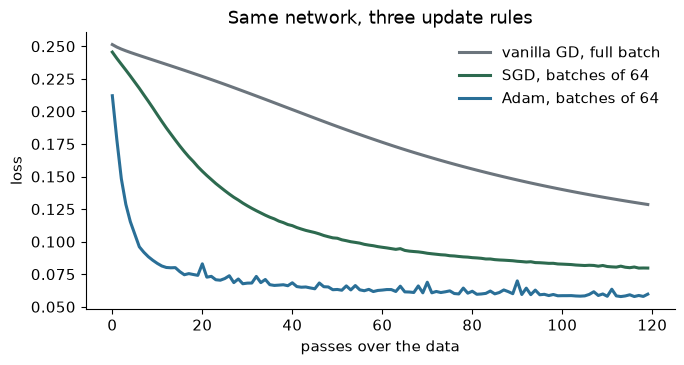

In [30]:
print("final losses: vanilla %.4f,  SGD %.4f,  Adam %.4f"
      % (hist_vanilla[-1], hist_sgd[-1], hist_adam[-1]))

fig, ax = plt.subplots(figsize=(7.6, 3.6))
ax.plot(hist_vanilla, color="#6c757d", lw=2.2, label="vanilla GD, full batch")
ax.plot(hist_sgd, color="#2d6a4f", lw=2.2, label="SGD, batches of 64")
ax.plot(hist_adam, color="#2a6f97", lw=2.2, label="Adam, batches of 64")
ax.set_xlabel("passes over the data")
ax.set_ylabel("loss")
ax.legend(frameon=False)
ax.set_title("Same network, three update rules")
fig.savefig("assets/fig_optimizers.png", dpi=150, bbox_inches="tight")
plt.show()

Each update rule has its own comfortable learning rate, so we gave each one a rate it works well with. Adam is the default in practice because it is robust to the learning rate you chose, not because it is always better. When in doubt, start with Adam.

### The whole training loop, assembled

Week 03's training code, the whole of it, is now ten lines. A model, a loader, an optimizer, a loss, and a loop. Every step inside an object you can name and replace.

In [31]:
model = make_model()
opt = torch.optim.Adam(model.parameters(), lr=0.03)

for epoch in range(120):
    for xb, tb in loader:
        opt.zero_grad()
        loss = ((model(xb) - tb) ** 2).mean()
        loss.backward()
        opt.step()

with torch.no_grad():
    loss = ((model(X) - t) ** 2).mean()
    acc = ((model(X) > 0.5).float() == t).float().mean()
print("loss %.4f, accuracy %.3f" % (loss.item(), acc.item()))

loss 0.0597, accuracy 0.940
